**STEP 01 IMPORT LIBRARIES**

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

**STEP 02 LOAD DATASET**

In [ ]:
df = pd.read_csv("cleaned_accessibility_dataset.csv")
df.head()

,Location_ID,Location_Name,Location_Type,City,State,Latitude,Longitude,Ownership_Type,Building_Age_Years,Last_Renovation_Years_Ago,...,Complaint_Resolution_Days,Accessibility_Complaints,User_Rating,Google_Maps_Rating,Last_Inspection_Months,Lift_Condition,Emergency_Exit_Accessibility,Accessibility_Score,Accessibility_Category,Improvement_Priority
0,LOC0001,Kolkata Botanical Garden,8,13,14,22.691764,88.446606,1,168,32.0,...,13.0,3,1.8,1.8,12.0,1,1,47.2,Poor,Medium
1,LOC0002,Hyderabad Municipal Office,3,8,12,17.236120,78.585714,1,57,12.0,...,12.0,3,1.9,1.8,15.0,1,0,36.1,Poor,High
2,LOC0003,Thane Government College,2,22,9,19.107785,73.081622,1,48,20.0,...,17.0,6,1.6,1.5,12.0,2,2,50.3,Poor,High
3,LOC0004,Nashik Green Park,6,18,9,19.849054,73.865693,1,38,22.0,...,21.0,5,3.2,3.1,12.0,1,1,38.2,Poor,High
4,LOC0005,Patna Domestic Airport,0,19,2,25.647041,85.202726,1,5,5.0,...,10.0,4,4.4,4.3,18.0,1,2,100.0,Excellent,Low


**STEP 03 CHECK COLUMNS**

In [ ]:
print(df.columns.tolist())

['Location_ID', 'Location_Name', 'Location_Type', 'City', 'State', 'Latitude', 'Longitude', 'Ownership_Type', 'Building_Age_Years', 'Last_Renovation_Years_Ago', 'Number_of_Floors', 'Ramp_Available', 'Elevator_Available', 'Wheelchair_Entrance', 'Braille_Signage', 'Audio_Announcements', 'Accessible_Washroom', 'Tactile_Path', 'Reserved_Parking', 'Door_Width_cm', 'Footpath_Condition', 'Lighting', 'Safety_Level', 'CCTV_Available', 'Staff_Trained_Accessibility', 'Multilingual_Signage', 'Public_Transport_Nearby', 'Parking_Available', 'Crowd_Level', 'Average_Waiting_Time', 'Daily_Footfall', 'Staff_Count', 'Budget_Allocated_Lakh_INR', 'Complaint_Resolution_Days', 'Accessibility_Complaints', 'User_Rating', 'Google_Maps_Rating', 'Last_Inspection_Months', 'Lift_Condition', 'Emergency_Exit_Accessibility', 'Accessibility_Score', 'Accessibility_Category', 'Improvement_Priority']


# ** STEP 4CREATE NEW FEATURES**

**1. INFRASTRUCTURE SCORE**

In [ ]:
infrastructure_features = [
    "Ramp_Available",
    "Elevator_Available",
    "Wheelchair_Entrance",
    "Accessible_Washroom",
    "Reserved_Parking"
]

df["Infrastructure_Score"] = df[infrastructure_features].sum(axis=1)

**2. ACCESSIBILITY SUPPORT SCORE**

In [ ]:
support_features = [
    "Braille_Signage",
    "Audio_Announcements",
    "Tactile_Path"
]

df["Accessibility_Support_Score"] = df[support_features].sum(axis=1)


**3. SAFETY INDEX**

In [ ]:
safety_features = [
    "Lighting",
    "Safety_Level",
    "CCTV_Available"
]
df["Safety_Index"] = df[safety_features].sum(axis=1)

**4. FACILITY SCORE**

In [ ]:
facility_features = [
    "Parking_Available",
    "Public_Transport_Nearby"
]

df["Facility_Score"] = df[facility_features].sum(axis=1)

**5. CROWD RISK SCORE**

In [ ]:
df["Crowd_Risk"] = (
    df["Crowd_Level"] *
    df["Average_Waiting_Time"]
)

**6. COMPLAINT RATE**

In [ ]:
df["Complaint_Rate"] = (
    df["Accessibility_Complaints"] /
    (df["Daily_Footfall"] + 1)
)

**7. ACCESSIBILITY EFFICIENCY**

In [ ]:
df["Accessibility_Efficiency"] = (
    df["Accessibility_Score"] /
    (df["Average_Waiting_Time"] + 1)
)

**STEP 5 VERIFY NEW FEATURES**

In [ ]:
new_features = [
    "Infrastructure_Score",
    "Accessibility_Support_Score",
    "Safety_Index",
    "Facility_Score",
    "Crowd_Risk",
    "Complaint_Rate",
    "Accessibility_Efficiency"
]

df[new_features].head()

,Infrastructure_Score,Accessibility_Support_Score,Safety_Index,Facility_Score,Crowd_Risk,Complaint_Rate,Accessibility_Efficiency
0,1,0,0,0,5.0,0.013953,7.866667
1,1,1,5,2,40.0,0.001073,1.719048
2,2,1,2,1,18.0,0.001603,2.647368
3,2,0,2,2,46.0,0.002014,1.591667
4,5,0,2,1,10.0,0.000409,16.666667


**STEP 06 CORRELATION WITH TARGET**

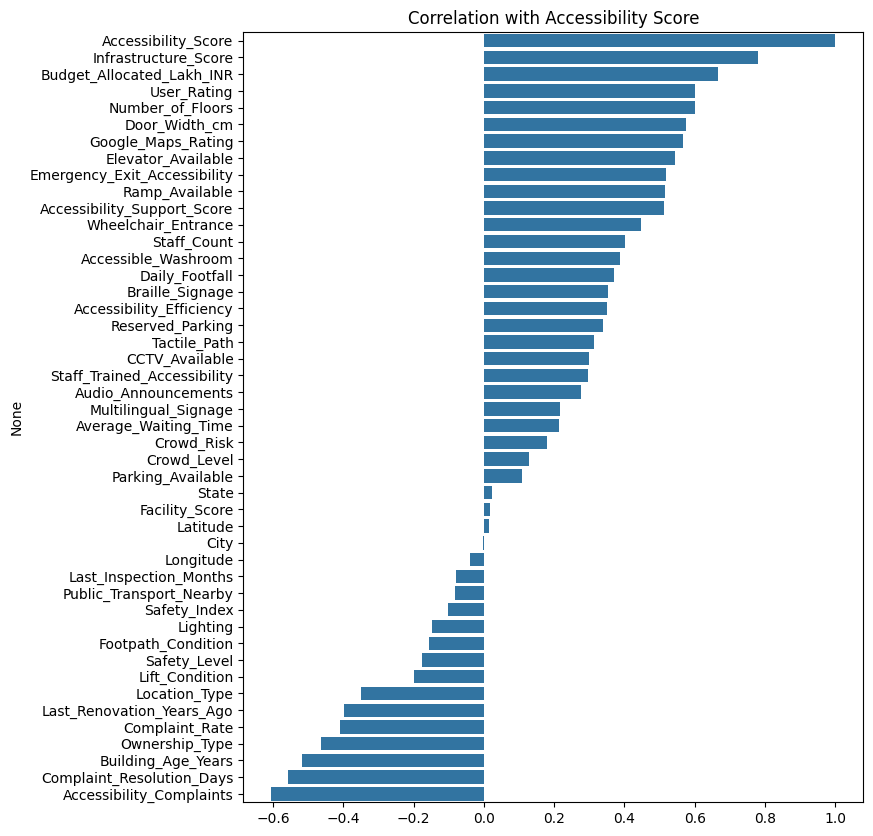

In [ ]:
corr = (
    df.corr(numeric_only=True)["Accessibility_Score"]
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,10))

sns.barplot(
    x=corr.values,
    y=corr.index
)

plt.title("Correlation with Accessibility Score")

plt.show()

**SAVE ENGINEERED DATASET**

In [ ]:
df.to_csv(
    "engineered_accessibility_dataset.csv",
    index=False
)